Couldn't import dot_parser, loading of dot files will not be possible.
Number of posts with both real and generated comments: 126


Computing similarities:   0%|          | 0/126 [00:00<?, ?it/s]

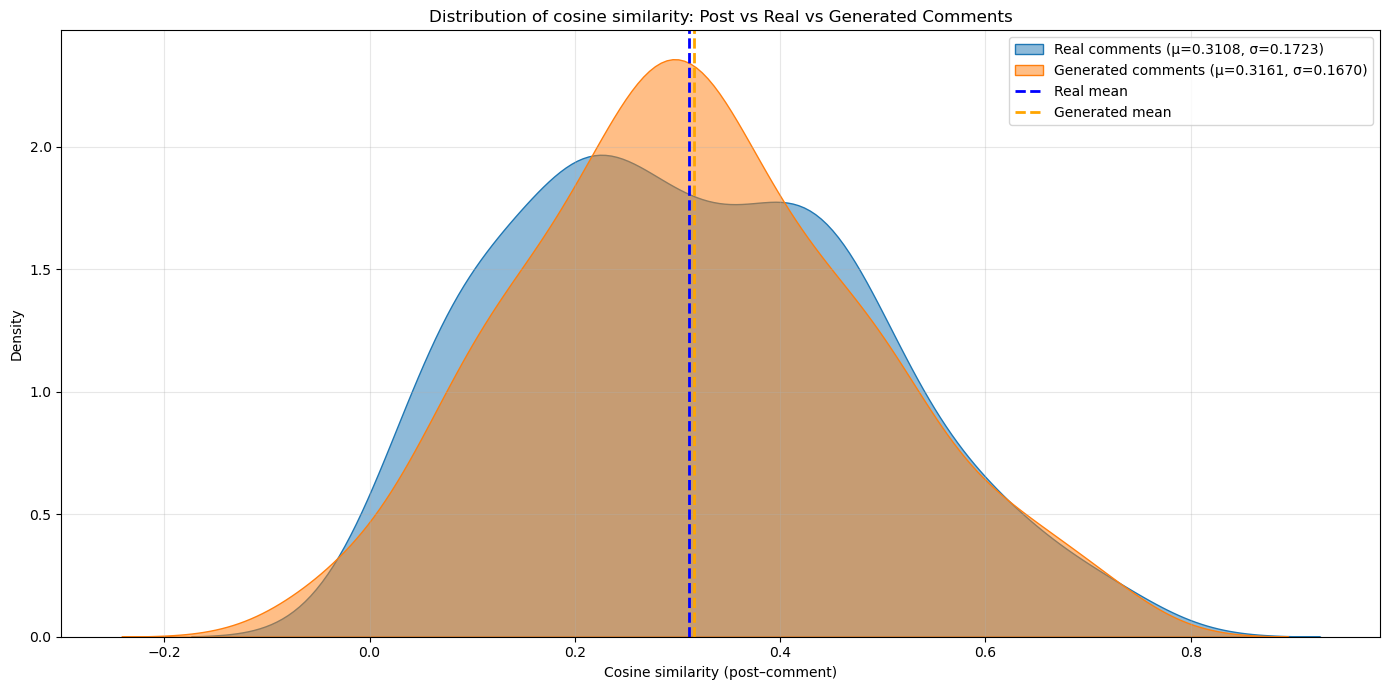

Per-comment statistics - REAL:
  Mean: 0.3108
  Std:  0.1723

Per-comment statistics - GENERATED:
  Mean: 0.3161
  Std:  0.1670


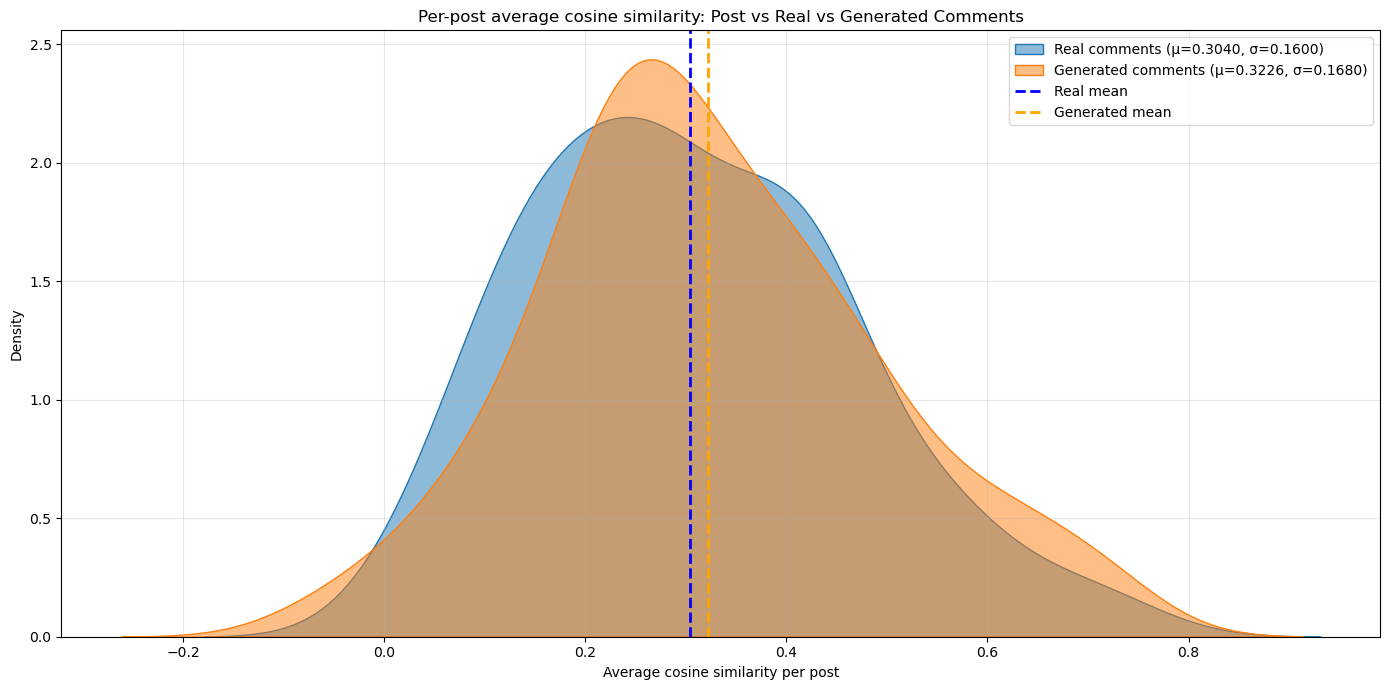


Per-post average statistics - REAL:
  Mean: 0.3040
  Std:  0.1600

Per-post average statistics - GENERATED:
  Mean: 0.3226
  Std:  0.1680


In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 1. Load data
# -------------------------------------------------------------------
gen_comments_df = pd.read_csv(
    r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_tune_qwen\generated_comments_qwen3.csv"
)
real_comments_df = pd.read_csv(
    r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_test_set.csv"
)

# # Keep only rows where post and comment exist
# real_comments_df = real_comments_df.dropna(subset=["text_ha", "text"])
# #gen_comments_df = gen_comments_df.dropna(subset=["Post", "Comments"])
# gen_comments_df = gen_comments_df.dropna(subset = ['post', 'generated_comment'])

# -------------------------------------------------------------------
# 2. Group comments by post
# -------------------------------------------------------------------
# Real: post = text_ha, comments = text
real_grouped = (
    real_comments_df.groupby("text_ha")["text"]
    .apply(list)
    .reset_index(name="real_comments")
)

# Generated: post = post, comments = generated_comment
gen_grouped = (
    gen_comments_df.groupby("post")["generated_comment"]
    .apply(list)
    .reset_index(name="gen_comments")
)

# Keep only posts present in both real and generated
merged = pd.merge(
    real_grouped,
    gen_grouped,
    left_on="text_ha",
    right_on="post",
    how="inner",
)

print(f"Number of posts with both real and generated comments: {len(merged)}")

# -------------------------------------------------------------------
# 3. Encode posts, real comments, generated comments
# -------------------------------------------------------------------
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

posts = merged["post"].tolist()
post_embeddings = model.encode(
    posts, convert_to_tensor=True, normalize_embeddings=True
)

# Flatten real comments
all_real_comments = []
real_counts = []
for com_list in merged["real_comments"]:
    real_counts.append(len(com_list))
    all_real_comments.extend(com_list)

real_comment_embeddings = model.encode(
    all_real_comments, convert_to_tensor=True, normalize_embeddings=True
)

# Flatten generated comments
all_gen_comments = []
gen_counts = []
for com_list in merged["gen_comments"]:
    gen_counts.append(len(com_list))
    all_gen_comments.extend(com_list)

gen_comment_embeddings = model.encode(
    all_gen_comments, convert_to_tensor=True, normalize_embeddings=True
)

# -------------------------------------------------------------------
# 4. Compute similarities: post–real, post–generated
# -------------------------------------------------------------------
real_comment_sims_all = []     # similarity per real comment
gen_comment_sims_all = []      # similarity per generated comment
real_avg_sims_per_post = []    # average per post (real)
gen_avg_sims_per_post = []     # average per post (generated)

# For iterating through flattened embeddings
real_cursor = 0
gen_cursor = 0

for i in tqdm(range(len(merged)), desc="Computing similarities"):
    # Post embedding
    post_embed = post_embeddings[i].unsqueeze(0)

    # ----- Real comments -----
    n_real = real_counts[i]
    real_embeds = real_comment_embeddings[real_cursor: real_cursor + n_real]
    real_cursor += n_real

    if n_real > 0:
        sims_real = util.cos_sim(post_embed, real_embeds).squeeze().cpu().numpy()
        sims_real = np.atleast_1d(sims_real)
        real_comment_sims_all.extend(sims_real)
        real_avg_sims_per_post.append(sims_real.mean())
    else:
        real_avg_sims_per_post.append(np.nan)

    # ----- Generated comments -----
    n_gen = gen_counts[i]
    gen_embeds = gen_comment_embeddings[gen_cursor: gen_cursor + n_gen]
    gen_cursor += n_gen

    if n_gen > 0:
        sims_gen = util.cos_sim(post_embed, gen_embeds).squeeze().cpu().numpy()
        sims_gen = np.atleast_1d(sims_gen)
        gen_comment_sims_all.extend(sims_gen)
        gen_avg_sims_per_post.append(sims_gen.mean())
    else:
        gen_avg_sims_per_post.append(np.nan)

# Convert to numpy arrays
real_comment_sims_all = np.array(real_comment_sims_all)
gen_comment_sims_all = np.array(gen_comment_sims_all)

real_avg_sims_per_post = np.array(real_avg_sims_per_post)
gen_avg_sims_per_post = np.array(gen_avg_sims_per_post)

# Drop NaNs (if any posts had zero comments)
real_avg_sims_per_post = real_avg_sims_per_post[~np.isnan(real_avg_sims_per_post)]
gen_avg_sims_per_post = gen_avg_sims_per_post[~np.isnan(gen_avg_sims_per_post)]

# Calculate statistics
real_mean = real_comment_sims_all.mean()
real_std = real_comment_sims_all.std()
gen_mean = gen_comment_sims_all.mean()
gen_std = gen_comment_sims_all.std()

real_post_mean = real_avg_sims_per_post.mean()
real_post_std = real_avg_sims_per_post.std()
gen_post_mean = gen_avg_sims_per_post.mean()
gen_post_std = gen_avg_sims_per_post.std()

# -------------------------------------------------------------------
# 5. Plot distributions: per-comment similarities
# -------------------------------------------------------------------
plt.figure(figsize=(14, 7))

sns.kdeplot(
    real_comment_sims_all,
    fill=True,
    alpha=0.5,
    label=f"Real comments (μ={real_mean:.4f}, σ={real_std:.4f})",
)
sns.kdeplot(
    gen_comment_sims_all,
    fill=True,
    alpha=0.5,
    label=f"Generated comments (μ={gen_mean:.4f}, σ={gen_std:.4f})",
)

plt.axvline(real_mean, color="blue", linestyle="--", linewidth=2, label=f"Real mean")
plt.axvline(gen_mean, color="orange", linestyle="--", linewidth=2, label=f"Generated mean")

plt.title("Distribution of cosine similarity: Post vs Real vs Generated Comments")
plt.xlabel("Cosine similarity (post–comment)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Per-comment statistics - REAL:")
print(f"  Mean: {real_mean:.4f}")
print(f"  Std:  {real_std:.4f}")
print(f"\nPer-comment statistics - GENERATED:")
print(f"  Mean: {gen_mean:.4f}")
print(f"  Std:  {gen_std:.4f}")

# -------------------------------------------------------------------
# 6. (Optional) Plot distributions: per-post average similarity
# -------------------------------------------------------------------
plt.figure(figsize=(14, 7))

sns.kdeplot(
    real_avg_sims_per_post,
    fill=True,
    alpha=0.5,
    label=f"Real comments (μ={real_post_mean:.4f}, σ={real_post_std:.4f})",
)
sns.kdeplot(
    gen_avg_sims_per_post,
    fill=True,
    alpha=0.5,
    label=f"Generated comments (μ={gen_post_mean:.4f}, σ={gen_post_std:.4f})",
)

plt.axvline(real_post_mean, color="blue", linestyle="--", linewidth=2, label=f"Real mean")
plt.axvline(gen_post_mean, color="orange", linestyle="--", linewidth=2, label=f"Generated mean")

plt.title("Per-post average cosine similarity: Post vs Real vs Generated Comments")
plt.xlabel("Average cosine similarity per post")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPer-post average statistics - REAL:")
print(f"  Mean: {real_post_mean:.4f}")
print(f"  Std:  {real_post_std:.4f}")
print(f"\nPer-post average statistics - GENERATED:")
print(f"  Mean: {gen_post_mean:.4f}")
print(f"  Std:  {gen_post_std:.4f}")


JENSEN-SHANNON DIVERGENCE ANALYSIS
Per-Post Average Relatedness JS Divergence: 0.266836
JS Divergence (squared): 0.071201
JS Distance (0=identical, 1=completely different): 0.266836
Interpretation: Somewhat different distributions

Distribution Comparison:
Real comments - Mean: 0.3040, Std: 0.1600
Generated comments - Mean: 0.3330, Std: 0.1414
Difference in means: 0.0290


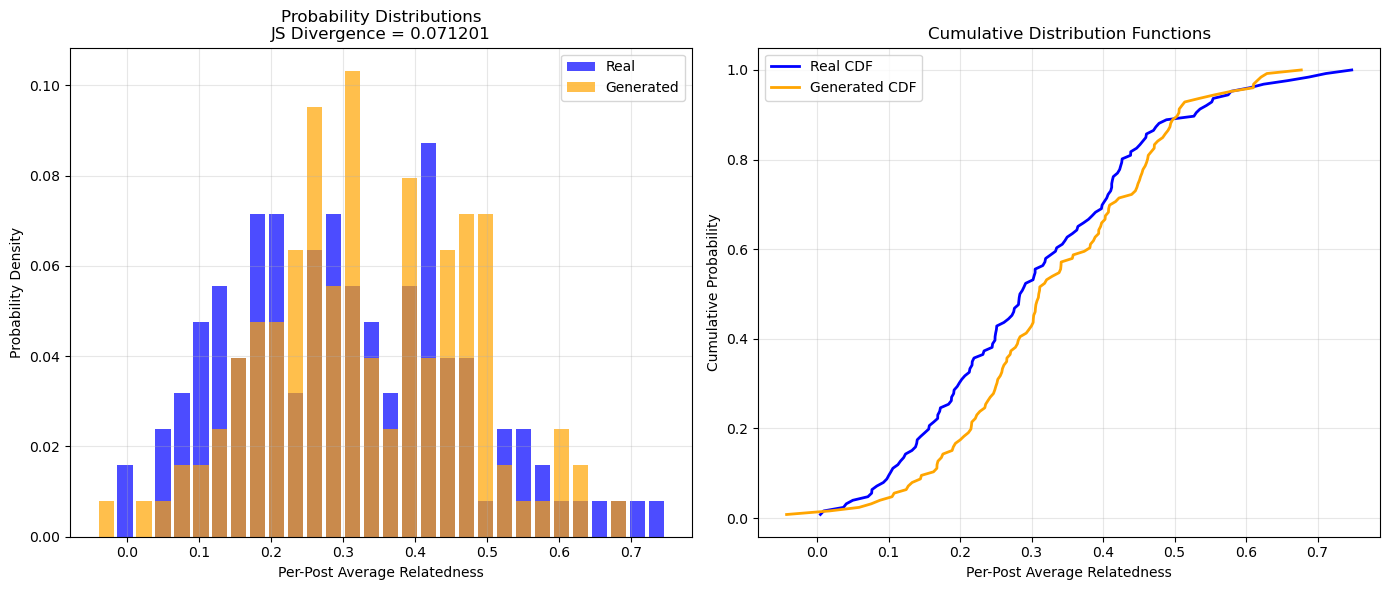

In [10]:
import numpy as np
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

# -------------------------------------------------------------------
# 7. Compute Jensen-Shannon Divergence for Per-Post Relatedness
# -------------------------------------------------------------------

def compute_js_divergence_from_samples(real_samples, gen_samples, n_bins=50):
    """
    Compute Jensen-Shannon divergence between two sample distributions
    by converting them to probability distributions using histograms.
    
    Args:
        real_samples: numpy array of real relatedness scores
        gen_samples: numpy array of generated relatedness scores  
        n_bins: number of bins for histogram
        
    Returns:
        js_divergence: Jensen-Shannon divergence value
    """
    
    # Define common range for both distributions
    min_val = min(real_samples.min(), gen_samples.min())
    max_val = max(real_samples.max(), gen_samples.max())
    bins = np.linspace(min_val, max_val, n_bins + 1)
    
    # Create histograms (probability distributions)
    real_hist, _ = np.histogram(real_samples, bins=bins, density=True)
    gen_hist, _ = np.histogram(gen_samples, bins=bins, density=True)
    
    # Normalize to probability distributions
    real_prob = real_hist / real_hist.sum()
    gen_prob = gen_hist / gen_hist.sum()
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    real_prob = real_prob + epsilon
    gen_prob = gen_prob + epsilon
    
    # Renormalize after adding epsilon
    real_prob = real_prob / real_prob.sum()
    gen_prob = gen_prob / gen_prob.sum()
    
    # Compute Jensen-Shannon divergence
    js_div = jensenshannon(real_prob, gen_prob)
    
    return js_div, real_prob, gen_prob, bins

# Compute JS divergence for per-post average relatedness
js_div_per_post, real_prob_dist, gen_prob_dist, bins = compute_js_divergence_from_samples(
    real_avg_sims_per_post, 
    gen_avg_sims_per_post, 
    n_bins=30
)

print("=" * 70)
print("JENSEN-SHANNON DIVERGENCE ANALYSIS")
print("=" * 70)
print(f"Per-Post Average Relatedness JS Divergence: {js_div_per_post:.6f}")
print(f"JS Divergence (squared): {js_div_per_post**2:.6f}")
print(f"JS Distance (0=identical, 1=completely different): {js_div_per_post:.6f}")

# Interpretation
if js_div_per_post < 0.1:
    interpretation = "Very similar distributions"
elif js_div_per_post < 0.2:
    interpretation = "Moderately similar distributions"  
elif js_div_per_post < 0.4:
    interpretation = "Somewhat different distributions"
else:
    interpretation = "Very different distributions"

print(f"Interpretation: {interpretation}")

# Additional statistics
print(f"\nDistribution Comparison:")
print(f"Real comments - Mean: {real_avg_sims_per_post.mean():.4f}, Std: {real_avg_sims_per_post.std():.4f}")
print(f"Generated comments - Mean: {gen_avg_sims_per_post.mean():.4f}, Std: {gen_avg_sims_per_post.std():.4f}")
print(f"Difference in means: {abs(real_avg_sims_per_post.mean() - gen_avg_sims_per_post.mean()):.4f}")

# Visualize the probability distributions used for JS divergence calculation
plt.figure(figsize=(14, 6))

# Plot the probability distributions
bin_centers = (bins[:-1] + bins[1:]) / 2
width = bins[1] - bins[0]

plt.subplot(1, 2, 1)
plt.bar(bin_centers, real_prob_dist, width=width*0.8, alpha=0.7, label='Real', color='blue')
plt.bar(bin_centers, gen_prob_dist, width=width*0.8, alpha=0.7, label='Generated', color='orange')
plt.title(f'Probability Distributions\nJS Divergence = {js_div_per_post**2:.6f}')
plt.xlabel('Per-Post Average Relatedness')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)

# Plot cumulative distributions for additional comparison
plt.subplot(1, 2, 2)
real_sorted = np.sort(real_avg_sims_per_post)
gen_sorted = np.sort(gen_avg_sims_per_post)
real_cdf = np.arange(1, len(real_sorted) + 1) / len(real_sorted)
gen_cdf = np.arange(1, len(gen_sorted) + 1) / len(gen_sorted)

plt.plot(real_sorted, real_cdf, label='Real CDF', color='blue', linewidth=2)
plt.plot(gen_sorted, gen_cdf, label='Generated CDF', color='orange', linewidth=2)
plt.title('Cumulative Distribution Functions')
plt.xlabel('Per-Post Average Relatedness')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

real_comments_df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v30_objectivee_buurman_new_data\llama-fb-comments-finetuned_v30_stratify_test_set_v30_generated.csv")
zero_shot = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Few Shot Prompt\LLAMA_3.2_3B_Instruct\llama_3.2_3B_few_shot_testset.csv")
objective = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v30_objectivee_buurman_new_data\llama-fb-comments-finetuned_v30_stratify_test_set_v30_generated.csv")
multiloss = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v39_v38_same_customwt_changed\llama-multitask-v39_KLlosssentiment_CElossintent_seplrate_test_set_v13_generated.csv")

# Fix rename: inplace=True returns None, so don't assign
zero_shot.rename(columns={"Post": "post", "Comments": "generated_comment"}, inplace=True)


def compute_relatedness_for_dataset(real_df, gen_df, model_name):
    """Compute post-comment relatedness for a given generated dataset"""

    real_grouped = (
        real_df.groupby("post")["true_comment"]
        .apply(list)
        .reset_index(name="real_comments")
    )

    gen_grouped = (
        gen_df.groupby("post")["generated_comment"]
        .apply(list)
        .reset_index(name="gen_comments")
    )

    merged = pd.merge(
        real_grouped,
        gen_grouped,
        left_on="post",
        right_on="post",
        how="inner",
    )

    if len(merged) == 0:
        print(f"Warning: No common posts found for {model_name}")
        return [], []

    print(f"{model_name}: {len(merged)} posts with both real and generated comments")

    model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

    posts = merged["post"].tolist()
    post_embeddings = model.encode(posts, convert_to_tensor=True, normalize_embeddings=True)

    all_real_comments = []
    real_counts = []
    for com_list in merged["real_comments"]:
        real_counts.append(len(com_list))
        all_real_comments.extend(com_list)

    all_gen_comments = []
    gen_counts = []
    for com_list in merged["gen_comments"]:
        gen_counts.append(len(com_list))
        all_gen_comments.extend(com_list)

    real_comment_embeddings = model.encode(all_real_comments, convert_to_tensor=True, normalize_embeddings=True)
    gen_comment_embeddings = model.encode(all_gen_comments, convert_to_tensor=True, normalize_embeddings=True)

    real_avg_sims_per_post = []
    gen_avg_sims_per_post = []

    real_cursor = 0
    gen_cursor = 0

    for i in tqdm(range(len(merged)), desc=f"Computing {model_name} similarities"):
        post_embed = post_embeddings[i].unsqueeze(0)

        n_real = real_counts[i]
        if n_real > 0:
            real_embeds = real_comment_embeddings[real_cursor: real_cursor + n_real]
            real_cursor += n_real
            sims_real = util.cos_sim(post_embed, real_embeds).squeeze().cpu().numpy()
            sims_real = np.atleast_1d(sims_real)
            real_avg_sims_per_post.append(sims_real.mean())

        n_gen = gen_counts[i]
        if n_gen > 0:
            gen_embeds = gen_comment_embeddings[gen_cursor: gen_cursor + n_gen]
            gen_cursor += n_gen
            sims_gen = util.cos_sim(post_embed, gen_embeds).squeeze().cpu().numpy()
            sims_gen = np.atleast_1d(sims_gen)
            gen_avg_sims_per_post.append(sims_gen.mean())

    return np.array(real_avg_sims_per_post), np.array(gen_avg_sims_per_post)


# Compute relatedness for all models
print("Computing relatedness metrics for all models...")
real_sims_obj, gen_sims_obj = compute_relatedness_for_dataset(real_comments_df, objective, "Objective (v30)")
real_sims_ml, gen_sims_ml = compute_relatedness_for_dataset(real_comments_df, multiloss, "Multiloss (v39)")
real_sims_zs, gen_sims_zs = compute_relatedness_for_dataset(real_comments_df, zero_shot, "Zero Shot")

real_relatedness = real_sims_obj

# Create comprehensive comparison plot
plt.figure(figsize=(16, 10))

data_for_box = [real_relatedness, gen_sims_obj, gen_sims_ml, gen_sims_zs]
labels_box   = ['Real', 'Objective (v30)', 'Multiloss (v39)', 'Zero Shot']
colors_box   = ['skyblue', 'lightgreen', 'salmon', 'mediumpurple']

# Plot 1: Distribution comparison
plt.subplot(2, 2, 1)
for sims, label, color in zip(data_for_box, labels_box, colors_box):
    sns.kdeplot(sims, fill=True, alpha=0.7, label=f'{label} (μ={sims.mean():.3f})', color=color)
    plt.axvline(sims.mean(), color=color, linestyle='--', alpha=0.8)

plt.title('Relatedness Distribution: Real vs LLaMA Models', fontweight='bold', fontsize=12)
plt.xlabel('Post-Comment Cosine Similarity')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

# Plot 2: Box plot comparison
plt.subplot(2, 2, 2)
box_plot = plt.boxplot(data_for_box, labels=labels_box, patch_artist=True)
for patch, color in zip(box_plot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Relatedness Distribution Comparison', fontweight='bold', fontsize=12)
plt.ylabel('Post-Comment Similarity')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

# Plot 3: Violin plot
plt.subplot(2, 2, 3)
relatedness_data = []
model_labels = []
for sims, label in zip(data_for_box, labels_box):
    relatedness_data.extend(sims)
    model_labels.extend([label] * len(sims))

df_plot = pd.DataFrame({'Similarity': relatedness_data, 'Model': model_labels})
sns.violinplot(data=df_plot, x='Model', y='Similarity', palette=colors_box)
plt.title('Relatedness Distribution Shape Comparison', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

# Plot 4: Cumulative distributions
plt.subplot(2, 2, 4)
for sims, label, color in zip(data_for_box, labels_box, colors_box):
    sorted_sims = np.sort(sims)
    cdf = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
    plt.plot(sorted_sims, cdf, label=label, color=color, linewidth=2, alpha=0.8)

plt.title('Cumulative Distribution Functions', fontweight='bold', fontsize=12)
plt.xlabel('Post-Comment Similarity')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive statistics
print("\n" + "=" * 80)
print("COMPREHENSIVE RELATEDNESS ANALYSIS")
print("=" * 80)

models_data = list(zip(labels_box, data_for_box))

for model_name, sims in models_data:
    print(f"\n{model_name}:")
    print(f"  Mean:    {sims.mean():.4f}")
    print(f"  Std:     {sims.std():.4f}")
    print(f"  Min:     {sims.min():.4f}")
    print(f"  Max:     {sims.max():.4f}")
    print(f"  Median:  {np.median(sims):.4f}")
    print(f"  Samples: {len(sims)}")

print(f"\n{'COMPARISON WITH REAL DATA'}")
print("=" * 50)
for model_name, sims in models_data[1:]:
    mean_diff = abs(sims.mean() - real_relatedness.mean())
    std_diff = abs(sims.std() - real_relatedness.std())
    print(f"\n{model_name} vs Real:")
    print(f"  Mean difference: {mean_diff:.4f}")
    print(f"  Std difference:  {std_diff:.4f}")


In [ ]:
from scipy.spatial.distance import jensenshannon

def compute_js_divergence(real_samples, gen_samples, n_bins=30):
    """Compute Jensen-Shannon divergence between two sample distributions."""
    min_val = min(real_samples.min(), gen_samples.min())
    max_val = max(real_samples.max(), gen_samples.max())
    bins = np.linspace(min_val, max_val, n_bins + 1)

    real_hist, _ = np.histogram(real_samples, bins=bins, density=True)
    gen_hist, _ = np.histogram(gen_samples, bins=bins, density=True)

    epsilon = 1e-10
    real_prob = (real_hist + epsilon) / (real_hist + epsilon).sum()
    gen_prob  = (gen_hist  + epsilon) / (gen_hist  + epsilon).sum()

    return jensenshannon(real_prob, gen_prob)


# Models to compare against real
gen_models = [
    ("Objective (v30)", gen_sims_obj),
    ("Multiloss (v39)", gen_sims_ml),
    ("Zero Shot",       gen_sims_zs),
]

rows = []
for model_name, gen_sims in gen_models:
    js = compute_js_divergence(real_relatedness, gen_sims)
    rows.append({
        "Model":             model_name,
        "JS Distance":       round(js, 6),
        "JS Distance²":      round(js ** 2, 6),
        "Mean (real)":       round(real_relatedness.mean(), 4),
        "Mean (gen)":        round(gen_sims.mean(), 4),
        "Δ Mean":            round(abs(gen_sims.mean() - real_relatedness.mean()), 4),
        "Std (real)":        round(real_relatedness.std(), 4),
        "Std (gen)":         round(gen_sims.std(), 4),
        "Δ Std":             round(abs(gen_sims.std() - real_relatedness.std()), 4),
        "Interpretation":    (
            "Very similar"       if js < 0.1 else
            "Moderately similar" if js < 0.2 else
            "Somewhat different" if js < 0.4 else
            "Very different"
        ),
    })

js_table = pd.DataFrame(rows).set_index("Model")

print("=" * 80)
print("JENSEN-SHANNON DISTANCE vs REAL COMMENTS")
print("=" * 80)
print(js_table.to_string())
print()
print("Note: JS Distance ranges from 0 (identical) to 1 (completely different)")

js_table


In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_training_set.csv")
# Group comments by post to capture comment counts per post (sustainability)

# Encode posts from Sustainability
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
# Encode comments from Other Topics

for i, row in df.iterrows():
    if pd.isna(row["Similarity"]):
        post_embed = model.encode(row["text_ha"], convert_to_tensor=True, normalize_embeddings=True).unsqueeze(0)
        comment_embed = model.encode(row["text"], convert_to_tensor=True, normalize_embeddings=True).unsqueeze(0)
        sim = util.cos_sim(post_embed, comment_embed).item()
        df.at[i, "Similarity"] = sim  # ← writes back to the actual dataframe






In [ ]:
df

In [ ]:
df.to_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_training_set.csv", index=False)